## Medical disease prediction


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

## Load Dataset


In [3]:
df = pd.read_csv(r"Data\medical_disease_prediction_10000.csv")
df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,Male,17.5,102,177,161,88,No,No,Medium,No,Healthy
1,69,Male,31.1,118,256,147,92,No,No,High,Yes,Pre-Diabetes
2,61,Female,31.3,114,206,193,74,Yes,No,Medium,No,Healthy
3,47,Female,23.9,105,162,253,68,No,No,Low,No,Healthy
4,47,Male,28.3,148,121,280,84,No,Yes,High,No,Healthy


In [4]:
df.shape

(10000, 12)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               10000 non-null  int64  
 1   Gender            10000 non-null  str    
 2   BMI               10000 non-null  float64
 3   BloodPressure     10000 non-null  int64  
 4   GlucoseLevel      10000 non-null  int64  
 5   Cholesterol       10000 non-null  int64  
 6   HeartRate         10000 non-null  int64  
 7   Smoking           10000 non-null  str    
 8   Alcohol           10000 non-null  str    
 9   PhysicalActivity  10000 non-null  str    
 10  FamilyHistory     10000 non-null  str    
 11  Disease           10000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 937.6 KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace = True)
df.dropna(inplace = True)
df.shape

(10000, 12)

## Target Column Analysis

In [8]:
df['Disease'].value_counts()

Disease
Healthy          6329
Hypertension     1771
Pre-Diabetes     1453
Heart Disease     232
Diabetes          215
Name: count, dtype: int64

In [9]:
df['Disease'].value_counts(normalize = True) * 100

Disease
Healthy          63.29
Hypertension     17.71
Pre-Diabetes     14.53
Heart Disease     2.32
Diabetes          2.15
Name: proportion, dtype: float64

## EDA Graphs

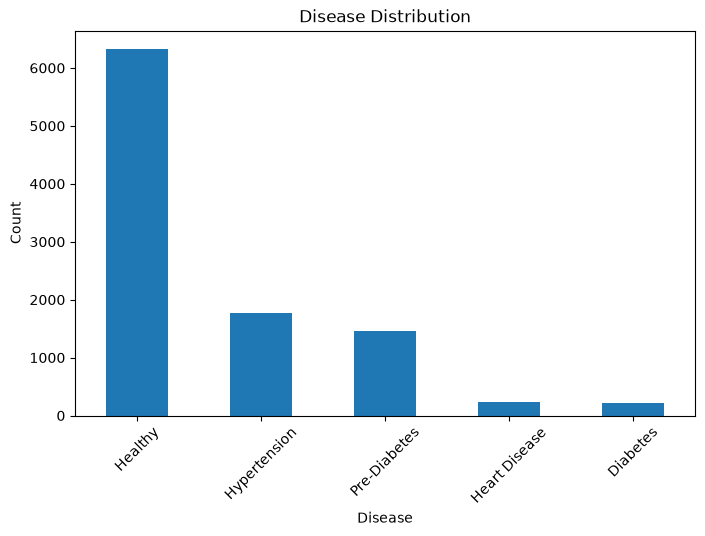

In [10]:
plt.figure(figsize=(8,5))
df['Disease'].value_counts().plot(kind = 'bar')
plt.title('Disease Distribution')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation = 45)
plt.show()

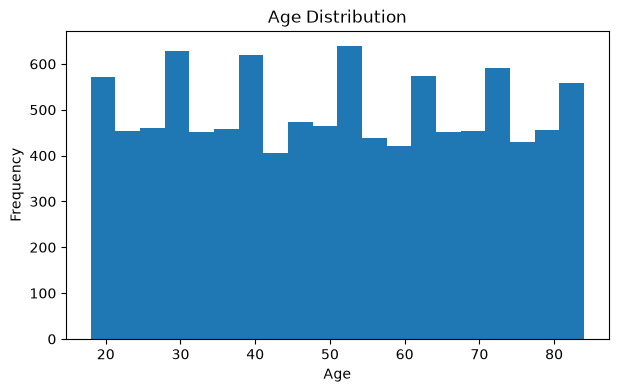

In [11]:
plt.figure(figsize = (7,4))
df['Age'].plot(kind='hist',bins = 20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.show()

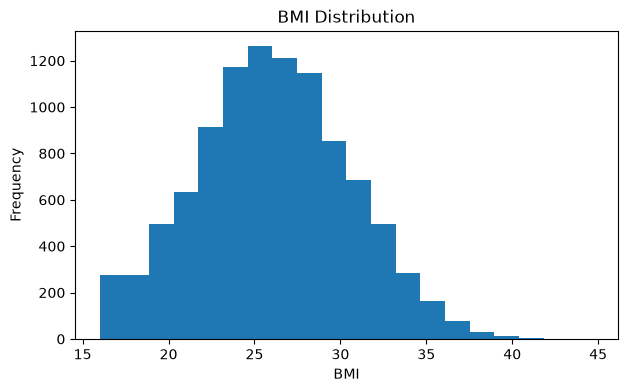

In [12]:
plt.figure(figsize = (7,4))
df['BMI'].plot(kind = 'hist',bins = 20)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.show()

## Encoding Categorial Columns

In [13]:
df['Gender'].unique(),df['Smoking'].unique(),df['Alcohol'].unique(),df['PhysicalActivity'].unique(),df['FamilyHistory'].unique(),df['Disease'].unique()

(<StringArray>
 ['Male', 'Female']
 Length: 2, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['Medium', 'High', 'Low']
 Length: 3, dtype: str,
 <StringArray>
 ['No', 'Yes']
 Length: 2, dtype: str,
 <StringArray>
 ['Healthy', 'Pre-Diabetes', 'Hypertension', 'Heart Disease', 'Diabetes']
 Length: 5, dtype: str)

In [15]:
Gender_dict = {'Male':1,'Female' : 2}
Smoking_dict = {'No':1,'Yes' : 2}
Alcohol_dict = {'No':1,'Yes':2}
PhysicalActivity_dict = {'Low':1,'Medium':2,'High':3}
FamilyHistory_dict = {'No':1,'Yes':2}
Disease_dict = {'Healthy' : 0,'Hypertension':1,'Pre-Diabetes':2,'Heart Disease':3,'Diabetes':4}

df['Gender'] = df['Gender'].map(Gender_dict)
df['Smoking'] = df['Smoking'].map(Smoking_dict)
df['Alcohol'] = df['Alcohol'].map(Alcohol_dict)
df['PhysicalActivity'] = df['PhysicalActivity'].map(PhysicalActivity_dict)
df['FamilyHistory'] = df['FamilyHistory'].map(FamilyHistory_dict)
df['Disease'] = df['Disease'].map(Disease_dict)


df.head()

,Age,Gender,BMI,BloodPressure,GlucoseLevel,Cholesterol,HeartRate,Smoking,Alcohol,PhysicalActivity,FamilyHistory,Disease
0,23,NaN,17.5,102,177,161,88,NaN,NaN,NaN,NaN,0
1,69,NaN,31.1,118,256,147,92,NaN,NaN,NaN,NaN,2
2,61,NaN,31.3,114,206,193,74,NaN,NaN,NaN,NaN,0
3,47,NaN,23.9,105,162,253,68,NaN,NaN,NaN,NaN,0
4,47,NaN,28.3,148,121,280,84,NaN,NaN,NaN,NaN,0


In [17]:
df.isnull().sum()

Age                     0
Gender              10000
BMI                     0
BloodPressure           0
GlucoseLevel            0
Cholesterol             0
HeartRate               0
Smoking             10000
Alcohol             10000
PhysicalActivity    10000
FamilyHistory       10000
Disease                 0
dtype: int64

## Correlation Heatmap

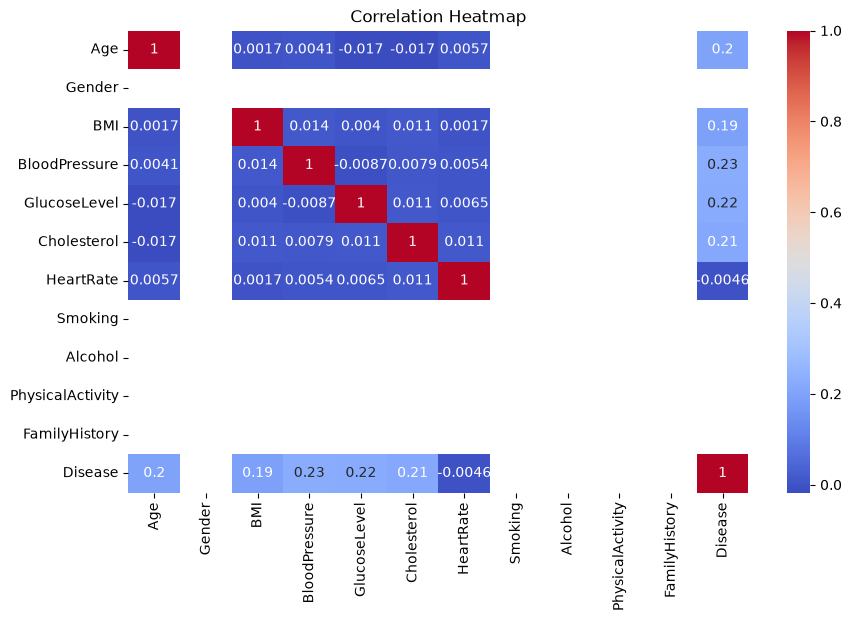

In [19]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(),annot = True,cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()
